# Forecast on characterization of microlensing events with ODI skipper

In [66]:
# np.log10(13)

np.float64(1.1139433523068367)

In [5]:
from astropy import units as u
np.log10(1e-9*u.M_earth.to('M_jup'))

np.float64(-11.502192710605739)

In [67]:

# loguni= []
# for i in range(10000):
#     loguni.append(lognuniform(low=-3, high=2, size=None,base=10))

# plt.hist(loguni, bins=np.logspace(-3,2,20))
# # plt.yscale("log")
# plt.xscale("log")

In [1]:
import pandas as pd
import numpy as np
import os,sys
import matplotlib.pyplot as plt
from astropy import units as u
# parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
sys.path.append('/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/')
from class_analysis import Analysis_Event
from Sim_Fit_Event import simulation_event
from ulens_params import microlensing_params
current_path = '/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/'
path_ephemerides= current_path+'/ephemerides/Roman_positions.npy'
path_dataslice = current_path+'/opsims/baseline/dataSlice.npy'

script_dir = '/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/'
ra, dec= 267.92497054815516, -29.152232510353276
system_type = 'lenses_low_mass'
model = 'FSPL'
orbital_period = 0
ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
      'i': 27.85, 'z': 27.46, 'y': 26.68}


/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


In [3]:

j=1
GENULENS_file =f"Genulens_chunk_{j}.csv"
TRILEGAL_file =f"TRILEGAL_chunk_{j}.csv"

path_TRILEGAL_set =str(script_dir)+f'/chunks_TRILEGAL_GENULENS/'+TRILEGAL_file 
path_GENULENS_set =str(script_dir)+f'/chunks_TRILEGAL_GENULENS/'+GENULENS_file 


einstein_time = []

from tqdm.auto import tqdm
for i in tqdm(range(10000)):
# i=347
    ROW = i-5000*int(i/5000)
    seed = i
    
    TRILEGAL_row = pd.read_csv(path_TRILEGAL_set, skiprows=ROW+1, nrows=1)
    TRILEGAL_row.columns = pd.read_csv(path_TRILEGAL_set, nrows=0).columns
    
    GENULENS_row = pd.read_csv(path_GENULENS_set, skiprows=ROW+1, nrows=1,header=None)  
    GENULENS_row.columns = pd.read_csv(path_GENULENS_set, nrows=0).columns

    
    
    event = simulation_event(ra, dec, i, path_ephemerides, path_dataslice,
                        TRILEGAL_row.iloc[0], GENULENS_row.iloc[0], system_type, model, orbital_period, 'test')
    
    einstein_time.append(event.event_param()['tE'])


100%|█████████████████████████████████████| 10000/10000 [03:37<00:00, 46.02it/s]


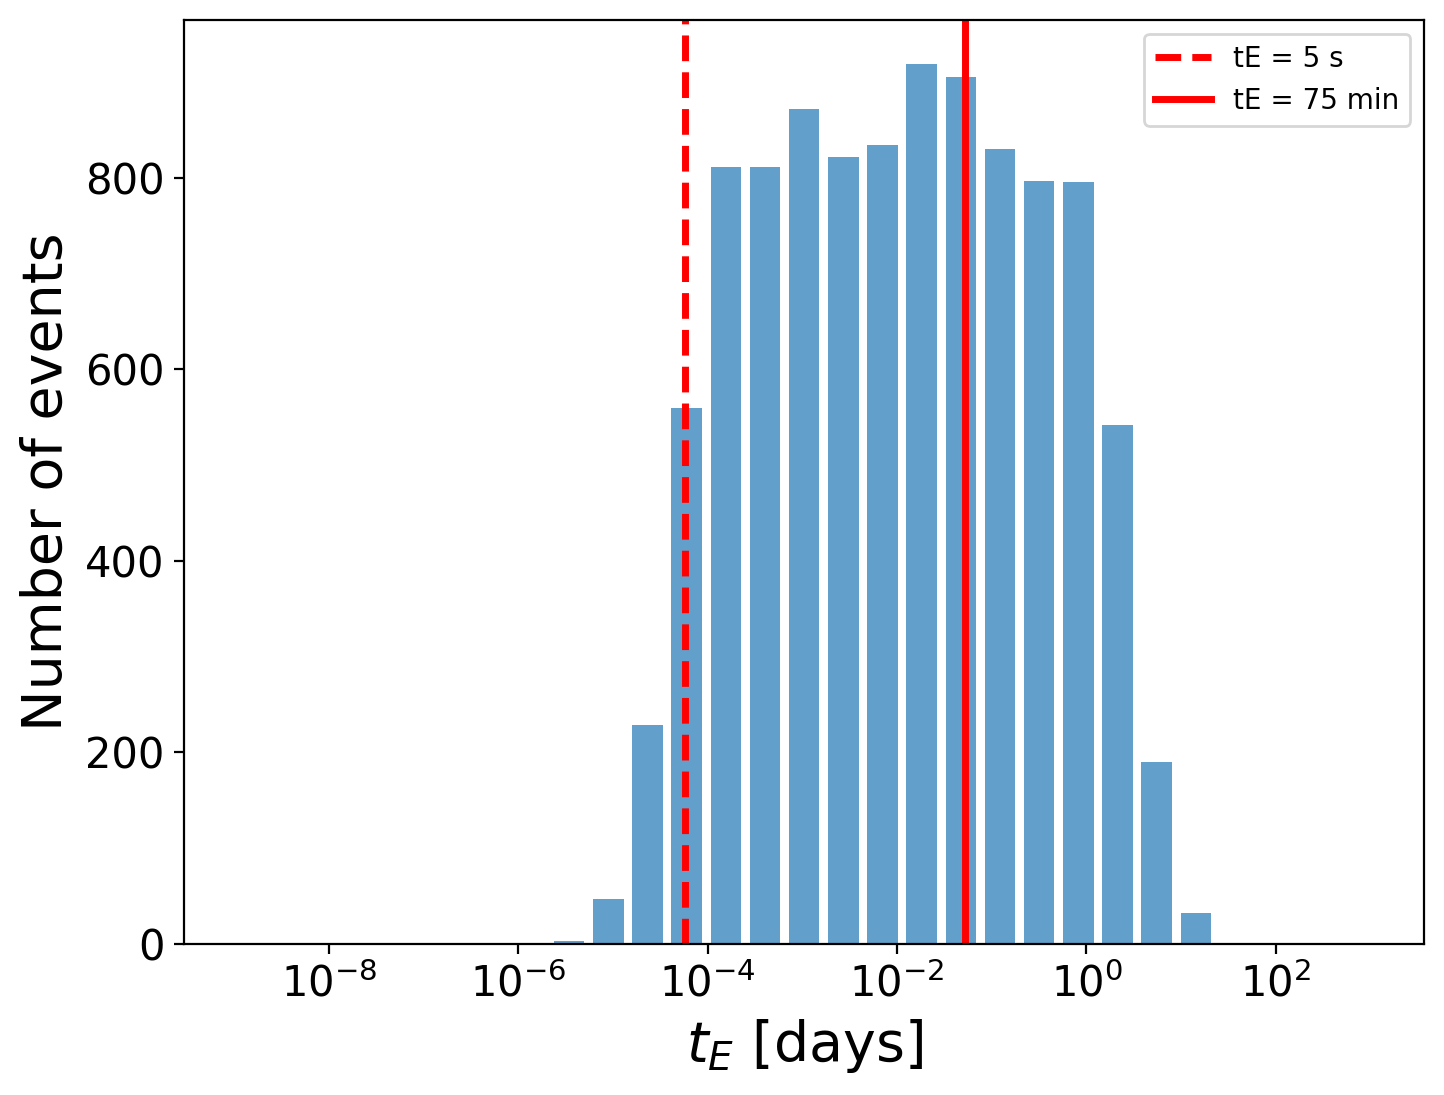

In [4]:
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# tE_cut = np.array(einstein_time)[(5.788e-5<np.array(einstein_time))&(0.052083333333333336>np.array(einstein_time))]
plt.figure(figsize=(8,6),dpi=200)
plt.hist(np.array(einstein_time), np.logspace(-9,3,30), rwidth=0.8,alpha=0.7)
plt.axvline(5.788e-5,color='red',ls='--',lw=2.5,label='tE = 5 s')
plt.axvline(0.052083333333333336,color='red',lw=2.5,label='tE = 75 min')

# plt.hist(tE_cut, np.logspace(-5,3,30), rwidth=0.8)

plt.ylabel('Number of events',fontsize=20)
plt.xlabel(r'$t_E$ [days]',fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
# plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best')
plt.savefig('/home/anibal-pc/proposal_odi/tE_mass_mincut_1e-6_MEarth.png')

# tE distribution of event with low mass lenses

In [30]:
def filter_ODI(telescope, pyLIMA_parameters):
    data_lc = telescope.lightcurve
    data_interval = data_lc[(data_lc['time'].value>pyLIMA_parameters['t0']-pyLIMA_parameters['tE'])&
        (data_lc['time'].value<pyLIMA_parameters['t0']+pyLIMA_parameters['tE'])]
    flag = {}

    if telescope.name == 'g':
        if len(data_interval[data_interval['mag']<21])>=5:
            flag[telescope.name]=1
        else:
            flag[telescope.name]=0
    else:    
        if len(data_interval[data_interval['err_mag']<1/7.2])>=5:
            flag[telescope.name]=1
        else:
            flag[telescope.name]=0
    return flag



In [33]:
def save_sim(iloc, path_TRILEGAL_set, path_to_save, my_own_model, pyLIMA_parameters, event_params):
    print('Saving Simulation...')
    # Save to an HDF5 file with specified names
    with h5py.File(path_to_save + 'Event_' + str(iloc) + '.h5', 'w') as file:
        # Save array with a specified name
        file.create_dataset('Data', data=np.array([iloc, path_TRILEGAL_set, my_own_model.origin[0]], dtype='S'))
        # Save dictionary with a specified name
        dict_group = file.create_group('pyLIMA_parameters')
        for key, value in pyLIMA_parameters.items():
            dict_group.attrs[key] = value
            
        dict_group_tril = file.create_group('TRILEGAL_params')
        for key, value in event_params.items():
            dict_group_tril.attrs[key] = value

        # Save table with a specified name
        for telo in my_own_model.event.telescopes:
            table = telo.lightcurve
            table_group = file.create_group(telo.name)
            for col in table.colnames:
                table_group.create_dataset(col, data=table[col])
    print('File saved:',path_to_save + 'Event_' + str(iloc) + '.h5' )


In [1]:
from tqdm.auto import tqdm
import h5py
j=1
GENULENS_file =f"Genulens_chunk_{j}.csv"
TRILEGAL_file =f"TRILEGAL_chunk_{j}.csv"

path_TRILEGAL_set =str(script_dir)+f'/chunks_TRILEGAL_GENULENS/'+TRILEGAL_file 
path_GENULENS_set =str(script_dir)+f'/chunks_TRILEGAL_GENULENS/'+GENULENS_file 
system_type = 'lenses_low_mass'
model = 'FSPL'
orbital_period = 0
ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
      'i': 27.85, 'z': 27.46, 'y': 26.68}

cols = ['Seed','mass','tE','rho','flag_roman','flag_ODI']
# df = pd.DataFrame(columns=cols)
output_path='/home/anibal-pc/proposal_odi/output.csv'
pd.DataFrame(columns=cols).to_csv(output_path, index=False)


for i in tqdm(range(1000)):
    ROW = i-5000*int(i/5000)
    seed = i
    
    TRILEGAL_row = pd.read_csv(path_TRILEGAL_set, skiprows=ROW+1, nrows=1)
    TRILEGAL_row.columns = pd.read_csv(path_TRILEGAL_set, nrows=0).columns
    
    GENULENS_row = pd.read_csv(path_GENULENS_set, skiprows=ROW+1, nrows=1,header=None)  
    GENULENS_row.columns = pd.read_csv(path_GENULENS_set, nrows=0).columns
    
    event = simulation_event(ra, dec, i, path_ephemerides, path_dataslice,
                        TRILEGAL_row.iloc[0], GENULENS_row.iloc[0], system_type, model, 0, 'test')

    tini,tfin = event.event_param()['t0']-1*event.event_param()['tE'],event.event_param()['t0']+1*event.event_param()['tE']
    timestamps = np.arange(tini,tfin,1/86400)
       
    if not event.event_param()['rho']>99:
        # if 2*event.event_param()['tE']*u.day.to('min')/15>5:
        event_dp0 = event.Event_roman_ODI({'g':timestamps})
        my_own_model2, pyLIMA_parameters = event.sim_clear_Rubin_lightcurves(event_dp0)
        flag_rom = filter_ODI(my_own_model2.event.telescopes[1], pyLIMA_parameters)
        # print(flag_rom['W149'])
        flag_odi = filter_ODI(my_own_model2.event.telescopes[0], pyLIMA_parameters)
    
        df.loc[len(df)] = [i, event.event_param()['mass'], event.event_param()['tE']
                           , event.event_param()['rho'], flag_rom['W149'], flag_odi['g']]
        mass = event.event_param()['mass']
        tE =  event.event_param()['tE']
        rho = event.event_param()['rho']
        flag_rom_val = flag_rom['W149']
        flag_odi_val = flag_odi['g']
        savepath = '/home/anibal-pc/proposal_odi/lightcurves/'
        save_sim_odi(i, savepath, my_own_model2, pyLIMA_parameters, mass, flag_rom_val, flag_odi_val)

/home/anibal-pc/anaconda3/envs/pyLIMA_updated/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'script_dir' is not defined

In [2]:
import h5py
import pandas as pd
import numpy as np
import os,sys
import matplotlib.pyplot as plt
from astropy import units as u
# parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
sys.path.append('/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/')
from class_analysis import Analysis_Event
from Sim_Fit_Event import simulation_event
from ulens_params import microlensing_params
current_path = '/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/'
path_ephemerides= current_path+'/ephemerides/Roman_positions.npy'
path_dataslice = current_path+'/opsims/baseline/dataSlice.npy'

script_dir = '/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/'

def filter_ODI(telescope, pyLIMA_parameters):
    data_lc = telescope.lightcurve
    data_interval = data_lc[(data_lc['time'].value>pyLIMA_parameters['t0']-pyLIMA_parameters['tE'])&
        (data_lc['time'].value<pyLIMA_parameters['t0']+pyLIMA_parameters['tE'])]
    flag = {}

    if telescope.name == 'g':
        if len(data_interval[data_interval['mag']<21])>=5:
            flag[telescope.name]=1
        else:
            flag[telescope.name]=0
    else:    
        if len(data_interval[data_interval['err_mag']<1/7.2])>=5:
            flag[telescope.name]=1
        else:
            flag[telescope.name]=0
    return flag


def save_sim_odi(iloc, path_to_save, my_own_model, pyLIMA_parameters, mass, flag_rom, flag_odi):
    print('Saving Simulation...')
    # Save to an HDF5 file with specified names
    with h5py.File(path_to_save + 'Event_' + str(iloc) + '.h5', 'w') as file:
        # Save array with a specified name
        file.create_dataset('Data', data=np.array([iloc, flag_rom, flag_odi, mass], dtype='f8'))
        # Save dictionary with a specified name
        dict_group = file.create_group('pyLIMA_parameters')
        for key, value in pyLIMA_parameters.items():
            dict_group.attrs[key] = value
            

        # Save table with a specified name
        for telo in my_own_model.event.telescopes:
            table = telo.lightcurve
            table_group = file.create_group(telo.name)
            for col in table.colnames:
                table_group.create_dataset(col, data=table[col])
    print('File saved:',path_to_save + 'Event_' + str(iloc) + '.h5' )


def odi_run(i,path_TRILEGAL_set, path_GENULENS_set,savepath ,  path_ephemerides, path_dataslice):
    ra, dec= 267.92497054815516, -29.152232510353276
    system_type = 'lenses_low_mass'
    model = 'FSPL'
    orbital_period = 0
    ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
          'i': 27.85, 'z': 27.46, 'y': 26.68}
    ROW = i-5000*int(i/5000)
    seed = i
    
    TRILEGAL_row = pd.read_csv(path_TRILEGAL_set, skiprows=ROW+1, nrows=1)
    TRILEGAL_row.columns = pd.read_csv(path_TRILEGAL_set, nrows=0).columns
    
    GENULENS_row = pd.read_csv(path_GENULENS_set, skiprows=ROW+1, nrows=1,header=None)  
    GENULENS_row.columns = pd.read_csv(path_GENULENS_set, nrows=0).columns
    
    event = simulation_event(ra, dec, i, path_ephemerides, path_dataslice,
                        TRILEGAL_row.iloc[0], GENULENS_row.iloc[0], system_type, model, 0, 'test')

    tini,tfin = event.event_param()['t0']-1*event.event_param()['tE'],event.event_param()['t0']+1*event.event_param()['tE']
    timestamps = np.arange(tini,tfin,1/86400)
       
    if not event.event_param()['rho']>99:
        ifdef read_data(path_model):
    # Open the HDF5 file and load data using specified names
    with h5py.File(path_model, 'r') as file:
        # Load array with string with info of dataset using its name
        info_dataset = file['Data'][:]
        info_dataset = [file['Data'][:][0].decode('UTF-8'), file['Data'][:][1].decode('UTF-8'),
                        [file['Data'][:][2].decode('UTF-8'), [0, 0]]]
        # Dictionary using its name
        pyLIMA_parameters = {key: file['pyLIMA_parameters'].attrs[key] for key in file['pyLIMA_parameters'].attrs}
        # Load table using its name
        bands = {}
        for band in ("W149", "u", "g", "r", "i", "z", "y"):
            loaded_table = QTable()
            for col in file[band]:
                loaded_table[col] = file[band][col][:]
            bands[band] = loaded_table
        return info_dataset, pyLIMA_parameters, bands
 2*event.event_param()['tE']*u.day.to('min')/15>5:
            event_dp0 = event.Event_roman_ODI({'g':timestamps})
            my_own_model2, pyLIMA_parameters = event.sim_clear_Rubin_lightcurves(event_dp0)
            flag_rom = filter_ODI(my_own_model2.event.telescopes[1], pyLIMA_parameters)
            # print(flag_rom['W149'])
            flag_odi = filter_ODI(my_own_model2.event.telescopes[0], pyLIMA_parameters)

            # df.loc[len(df)] = [i, event.event_param()['mass'], event.event_param()['tE']
            #                    , event.event_param()['rho'], flag_rom['W149'], flag_odi['g']]
            mass = event.event_param()['mass']
            tE =  event.event_param()['tE']
            rho = event.event_param()['rho']
            flag_rom_val = flag_rom['W149']
            flag_odi_val = flag_odi['g']
            
            save_sim_odi(i, savepath, my_own_model2, pyLIMA_parameters, mass, flag_rom_val, flag_odi_val)


from tqdm import tqdm
j=1
GENULENS_file =f"Genulens_chunk_{j}.csv"
TRILEGAL_file =f"TRILEGAL_chunk_{j}.csv"

path_TRILEGAL_set =str(script_dir)+f'/chunks_TRILEGAL_GENULENS/'+TRILEGAL_file 
path_GENULENS_set =str(script_dir)+f'/chunks_TRILEGAL_GENULENS/'+GENULENS_file 
savepath = '/home/anibal-pc/proposal_odi/lightcurves/'
for i in tqdm(range(2)):
    
    odi_run(i,path_TRILEGAL_set, path_GENULENS_set,savepath ,  path_ephemerides, path_dataslice)

  0%|                                                     | 0/2 [00:00<?, ?it/s]/home/anibal-pc/anaconda3/envs/pyLIMA_updated/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
 50%|██████████████████████▌                      | 1/2 [00:02<00:02,  2.87s/it]

Saving Simulation...
File saved: /home/anibal-pc/proposal_odi/lightcurves/Event_0.h5


/home/anibal-pc/anaconda3/envs/pyLIMA_updated/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
100%|█████████████████████████████████████████████| 2/2 [00:03<00:00,  1.94s/it]

Saving Simulation...
File saved: /home/anibal-pc/proposal_odi/lightcurves/Event_1.h5


/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


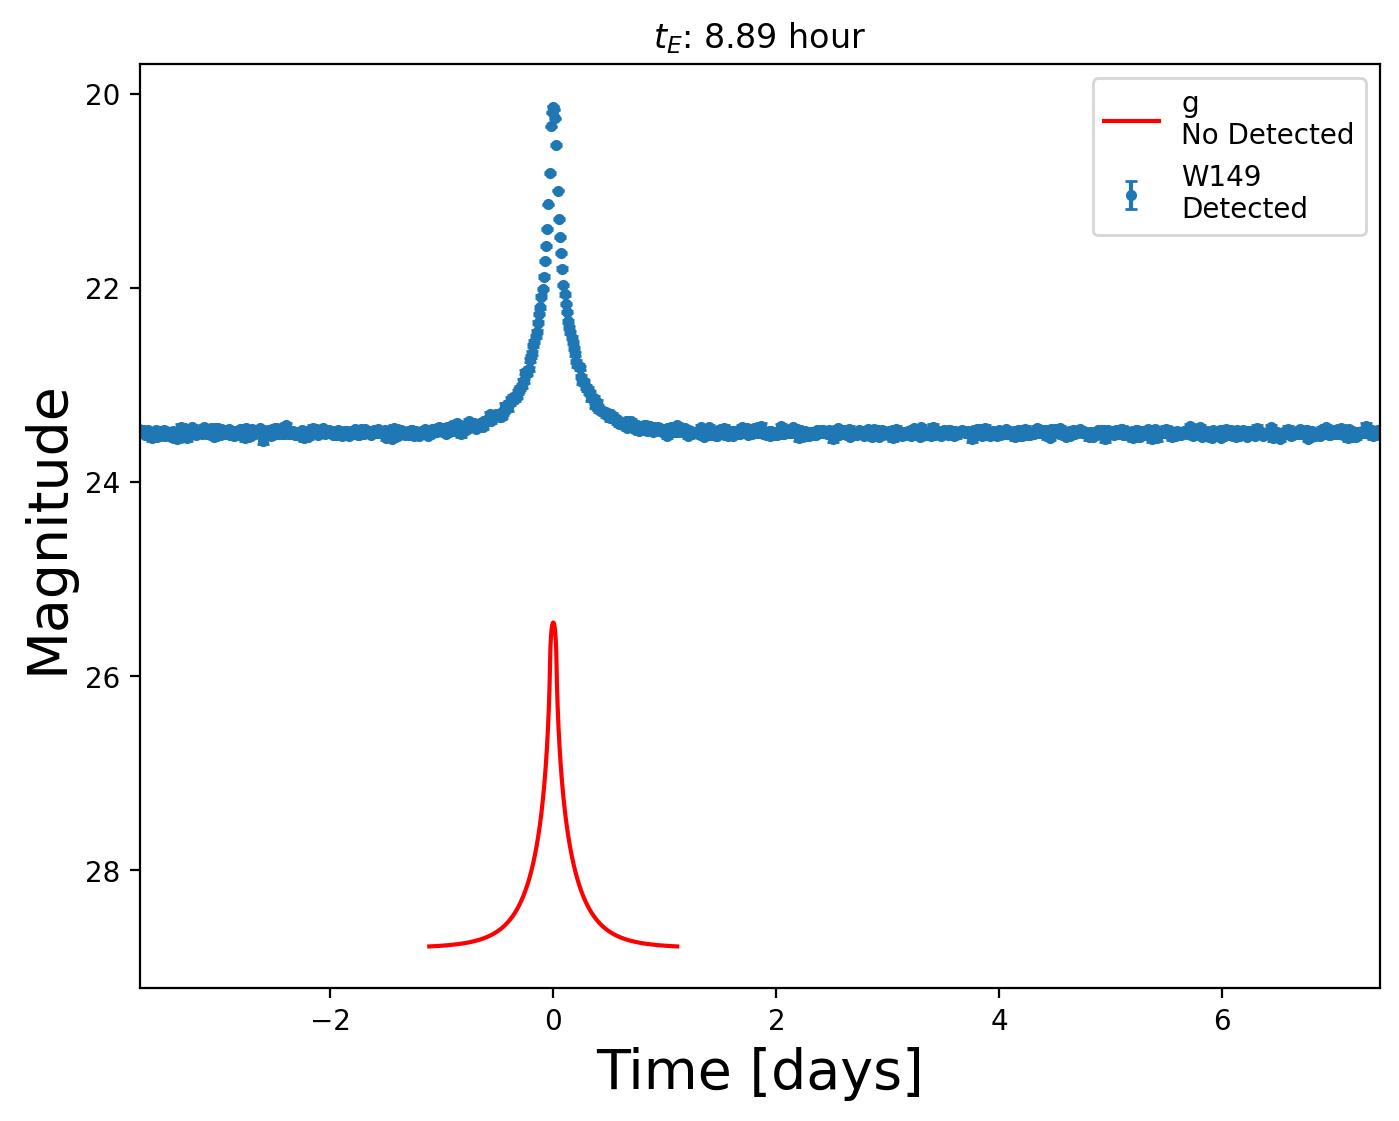

In [10]:
plt.figure(figsize=(8,6),dpi=200)
from functions_roman_rubin import mag

flag_rom = filter_ODI(my_own_model2.event.telescopes[1], pyLIMA_parameters)
plt.errorbar(    my_own_model2.event.telescopes[1].lightcurve['time'].value-pyLIMA_parameters['t0']
    ,my_own_model2.event.telescopes[1].lightcurve['mag'].value,my_own_model2.event.telescopes[1].lightcurve['err_mag'].value,marker='.',ls='',capsize=2,label=my_own_model2.event.telescopes[1].name+'\n'+str(flag_rom['W149']))


flag_odi = filter_ODI(my_own_model2.event.telescopes[0], pyLIMA_parameters)
plt.plot(    my_own_model2.event.telescopes[0].lightcurve['time'].value-pyLIMA_parameters['t0']
    ,mag(ZP['g'],my_own_model2.event.telescopes[0].lightcurve['flux'].value),color='red',label=my_own_model2.event.telescopes[0].name+'\n'+str(flag_odi['g']))
plt.xlim(-10*pyLIMA_parameters['tE'],+20*pyLIMA_parameters['tE'])
plt.title(r'$t_E$: '+str(round(pyLIMA_parameters['tE']*u.day.to('hour'),2))+' hour')
plt.legend(loc='best')
plt.gca().invert_yaxis()
plt.xlabel('Time [days]',fontsize=20)
plt.ylabel('Magnitude',fontsize=20)
plt.savefig('/home/anibal-pc/proposal_odi/event_tE_'+str(round(pyLIMA_parameters['tE']*u.day.to('hour'),2))+'_h.png')


In [14]:
flag_rom = filter_ODI(my_own_model2.event.telescopes[1], pyLIMA_parameters)

print(flag_rom['W149'])

flag_odi = filter_ODI(my_own_model2.event.telescopes[0], pyLIMA_parameters)

print(flag_odi['g'])



Detected
No Detected


In [ ]:
def read_data(path_model):
    # Open the HDF5 file and load data using specified names
    with h5py.File(path_model, 'r') as file:
        # Load array with string with info of dataset using its name
        info_dataset = file['Data'][:]
        info_dataset = [file['Data'][:][0].decode('UTF-8'), file['Data'][:][1].decode('UTF-8'),
                        [file['Data'][:][2].decode('UTF-8'), [0, 0]]]
        # Dictionary using its name
        pyLIMA_parameters = {key: file['pyLIMA_parameters'].attrs[key] for key in file['pyLIMA_parameters'].attrs}
        # Load table using its name
        bands = {}
        for band in ("W149", "g"):
            loaded_table = QTable()
            for col in file[band]:
                loaded_table[col] = file[band][col][:]
            bands[band] = loaded_table
        return info_dataset, pyLIMA_parameters, bands



In [10]:
import h5py
import numpy as np

def load_sim_odi(path_to_file):
    data = {}
    
    with h5py.File(path_to_file, 'r') as file:
        # Leer el array 'Data'
        raw_data = file['Data'][:]
        data['iloc'] = raw_data[0]
        data['flag_rom'] = raw_data[1]
        data['flag_odi'] = raw_data[2]
        data['mass'] = raw_data[3]

        # Leer atributos del diccionario pyLIMA_parameters
        pyLIMA_params = dict(file['pyLIMA_parameters'].attrs)
        data['pyLIMA_parameters'] = pyLIMA_params

        # Leer las curvas de luz de cada telescopio
        lightcurves = {}
        for tel_name in file:
            if tel_name in ['Data', 'pyLIMA_parameters']:
                continue  # Saltar estos grupos
            tel_group = file[tel_name]
            table = {col: tel_group[col][:] for col in tel_group}
            lightcurves[tel_name] = table

        data['lightcurves'] = lightcurves

    return data


load_sim_odi('/home/anibal-pc/proposal_odi/lightcurves/Event_0.h5')['flag_rom']

np.float64(1.0)

1464

In [29]:
from astropy import units as u

print(np.min(data['mass'][data['flag_rom']==1])*u.M_jup.to('M_earth'))
print(np.min(data['mass'][data['flag_odi']==1])*u.M_jup.to('M_earth'))



0.0020842208352669462
1.7725575549636643e-06


In [85]:
np.min(data['mass'][data['flag_rom']==1]*u.M_jup.to("M_earth"))

np.float64(0.0020842208352669462)

In [89]:
2e-3

0.002

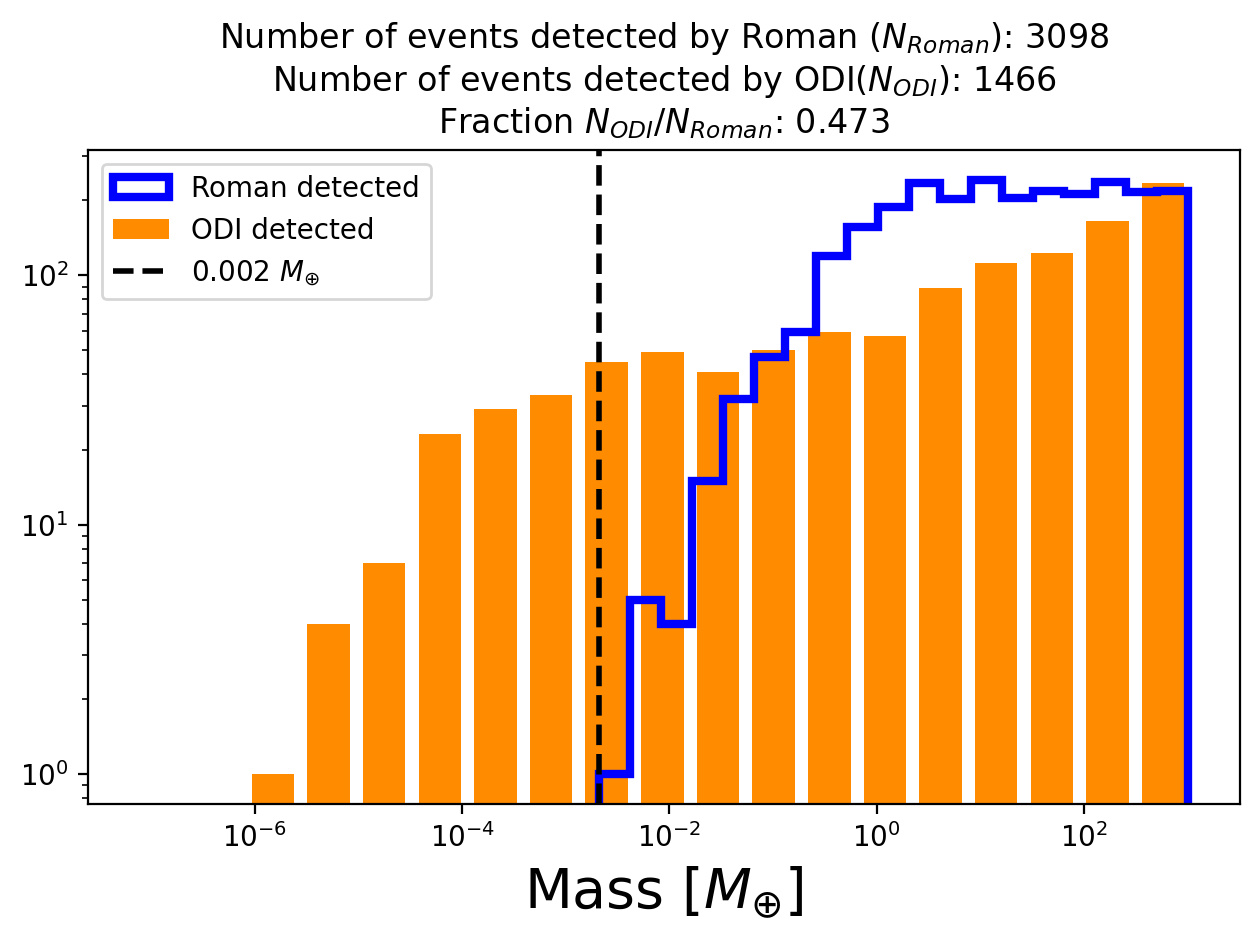

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv('/home/anibal-pc/output.csv')

plt.figure(dpi=200)
plt.hist(data['mass'][data['flag_rom']==1]*u.M_jup.to("M_earth"),bins=np.logspace(np.log10(np.min(data['mass'][data['flag_rom']==1]*u.M_jup.to("M_earth"))),3,20),rwidth=0.85,alpha=1,linewidth=3,histtype='step', edgecolor='blue' ,label='Roman detected')
plt.hist(data['mass'][data['flag_odi']==1]*u.M_jup.to("M_earth"),bins=np.logspace(-7-0.2,3,20),alpha=1,color='darkorange',rwidth=0.8,label='ODI detected')

plt.xscale('log')
plt.axvline(np.min(data['mass'][data['flag_rom']==1]*u.M_jup.to("M_earth")),ls='--',linewidth=2,color='k', label='0.002 $M_{\oplus}$')
plt.xlabel("Mass [$M_{\oplus}$]",fontsize=20)
nrom = len(data['mass'][data['flag_rom']==1])
nodi = len(data['mass'][data['flag_odi']==1])
plt.title(r'Number of events detected by Roman ($N_{Roman}$)'+f': {nrom}\nNumber of events detected by '+r'ODI($N_{ODI}$)'+f': {nodi}\nFraction '+ r'$N_{ODI}/N_{Roman}$'+f': {round(nodi/nrom,3)}')
# plt.title(f'Number of events detected by Roman:{nrom}\nNumber of events detected by ODI:{nodi}')
plt.legend(loc='best')
plt.yscale("log")
plt.tight_layout()
plt.savefig('/home/anibal-pc/proposal_odi/mass_histogram_flags.png')

In [ ]:
}